In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cement-prediction/CapstoneProject.xlsx


# Extract Data

In [2]:
data = pd.read_excel("/kaggle/input/cement-prediction/CapstoneProject.xlsx")
display(data.head())

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28,29.89
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14,23.51
2,250.0,0.0,95.7,187.4,5.5,956.9,861.2,28,29.22
3,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
4,154.8,183.4,0.0,193.3,9.1,1047.4,696.7,28,18.29


In [3]:
data.info()
data['age']=data['age'].astype(float)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


##### Output Feature : strength
##### Input Feature : Rest of the columns

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.167864,104.506364,102.00,192.375,272.900,350.000,540.0
slag,1030.0,73.895825,86.279342,0.00,0.000,22.000,142.950,359.4
ash,1030.0,54.188350,63.997004,0.00,0.000,0.000,118.300,200.1
water,1030.0,181.567282,21.354219,121.80,164.900,185.000,192.000,247.0
superplastic,1030.0,6.204660,5.973841,0.00,0.000,6.400,10.200,32.2
coarseagg,1030.0,972.918932,77.753954,801.00,932.000,968.000,1029.400,1145.0
fineagg,1030.0,773.580485,80.175980,594.00,730.950,779.500,824.000,992.6
age,1030.0,45.662136,63.169912,1.00,7.000,28.000,56.000,365.0
strength,1030.0,35.817961,16.705742,2.33,23.710,34.445,46.135,82.6


# Check for Outliers

cement             AxesSubplot(0.125,0.536818;0.133621x0.343182)
slag            AxesSubplot(0.285345,0.536818;0.133621x0.343182)
ash              AxesSubplot(0.44569,0.536818;0.133621x0.343182)
water           AxesSubplot(0.606034,0.536818;0.133621x0.343182)
superplastic    AxesSubplot(0.766379,0.536818;0.133621x0.343182)
coarseagg             AxesSubplot(0.125,0.125;0.133621x0.343182)
fineagg            AxesSubplot(0.285345,0.125;0.133621x0.343182)
age                 AxesSubplot(0.44569,0.125;0.133621x0.343182)
strength           AxesSubplot(0.606034,0.125;0.133621x0.343182)
dtype: object

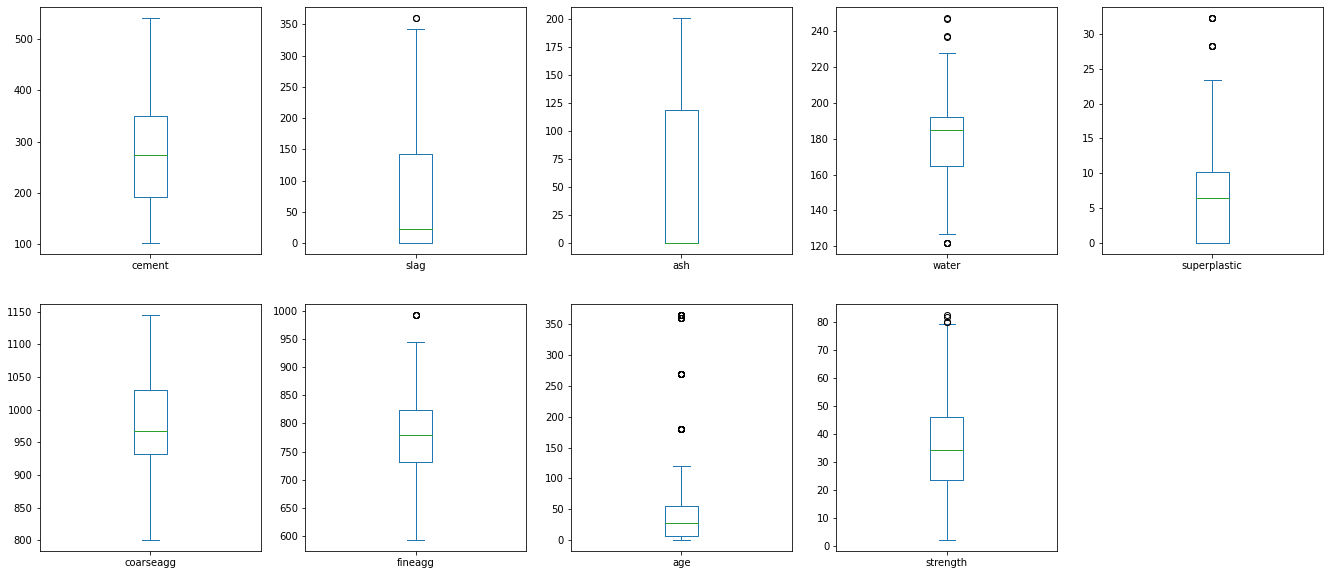

In [5]:
data.plot(kind='box', subplots=True, layout=(2,5), figsize=(23,10))

In [6]:
outlier=pd.DataFrame({})
for i in data.columns:
  q1=data[i].quantile(0.25)
  q3=data[i].quantile(0.75)
  iqr=q3-q1
  lw=q1-(1.5*iqr)
  uw=q3+(1.5*iqr)
  out=False
  if (data[i].min() < lw) or (data[i].max() > uw):
    out=True
  else:
    out=False
  outlier=outlier.append({
      'column_name':i,
      'min':data[i].min(),
      'max':data[i].max(),
      'mean':data[i].mean(),
      'std':data[i].std(),
      'lower_whisker':lw,
      'upper_whisker':uw,
      'has_outlier':out
  }, ignore_index = True)
  
display(outlier)

,column_name,min,max,mean,std,lower_whisker,upper_whisker,has_outlier
0,cement,102.00,540.0,281.167864,104.506364,-44.0625,586.4375,0.0
1,slag,0.00,359.4,73.895825,86.279342,-214.4250,357.3750,1.0
2,ash,0.00,200.1,54.188350,63.997004,-177.4500,295.7500,0.0
3,water,121.80,247.0,181.567282,21.354219,124.2500,232.6500,1.0
4,superplastic,0.00,32.2,6.204660,5.973841,-15.3000,25.5000,1.0
5,coarseagg,801.00,1145.0,972.918932,77.753954,785.9000,1175.5000,0.0
6,fineagg,594.00,992.6,773.580485,80.175980,591.3750,963.5750,1.0
7,age,1.00,365.0,45.662136,63.169912,-66.5000,129.5000,1.0
8,strength,2.33,82.6,35.817961,16.705742,-9.9275,79.7725,1.0


##### So, slag, water, superplastic, fineagg, age and strength have outliers.

# Removing Outliers

In [7]:
data2=data.copy()
for i in data2.columns:
  data2[i]=data2[data2[i]>(float(outlier[(outlier['column_name']==i)]['lower_whisker'].values))][i]
  data2[i]=data2[data2[i]<(float(outlier[(outlier['column_name']==i)]['upper_whisker'].values))][i]
  print("********")
  print(i, "min = ", data[i].min(), ">>", data2[i].min())
  print(i, "max = ", data[i].max(), ">>", data2[i].max())

********
cement min =  102.0 >> 102.0
cement max =  540.0 >> 540.0
********
slag min =  0.0 >> 0.0
slag max =  359.4 >> 342.1
********
ash min =  0.0 >> 0.0
ash max =  200.1 >> 200.1
********
water min =  121.8 >> 126.6
water max =  247.0 >> 228.0
********
superplastic min =  0.0 >> 0.0
superplastic max =  32.2 >> 23.4
********
coarseagg min =  801.0 >> 801.0
coarseagg max =  1145.0 >> 1145.0
********
fineagg min =  594.0 >> 594.0
fineagg max =  992.6 >> 945.0
********
age min =  1.0 >> 1.0
age max =  365.0 >> 120.0
********
strength min =  2.33 >> 2.33
strength max =  82.6 >> 79.4


cement             AxesSubplot(0.125,0.536818;0.133621x0.343182)
slag            AxesSubplot(0.285345,0.536818;0.133621x0.343182)
ash              AxesSubplot(0.44569,0.536818;0.133621x0.343182)
water           AxesSubplot(0.606034,0.536818;0.133621x0.343182)
superplastic    AxesSubplot(0.766379,0.536818;0.133621x0.343182)
coarseagg             AxesSubplot(0.125,0.125;0.133621x0.343182)
fineagg            AxesSubplot(0.285345,0.125;0.133621x0.343182)
age                 AxesSubplot(0.44569,0.125;0.133621x0.343182)
strength           AxesSubplot(0.606034,0.125;0.133621x0.343182)
dtype: object

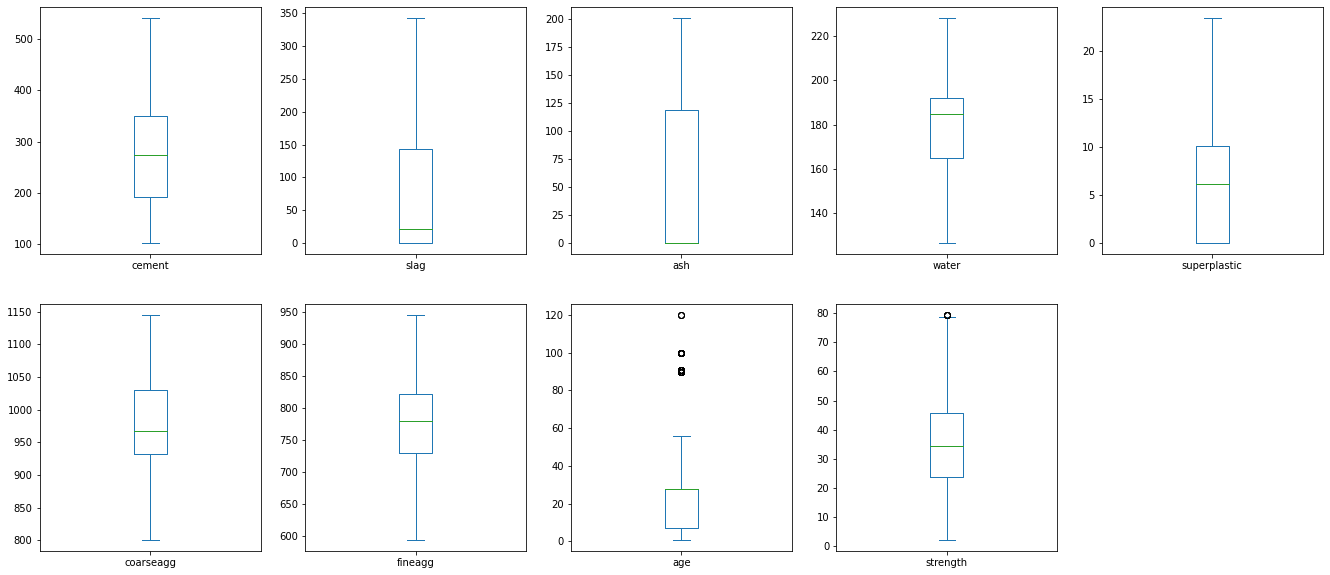

In [8]:
data2.plot(kind='box', subplots=True, layout=(2,5), figsize=(23,10))

Note: Though age and strength is showing outliers as they are calculated with new values of data. Original outliers have been removed.

# Check for Collinearity

<AxesSubplot:>

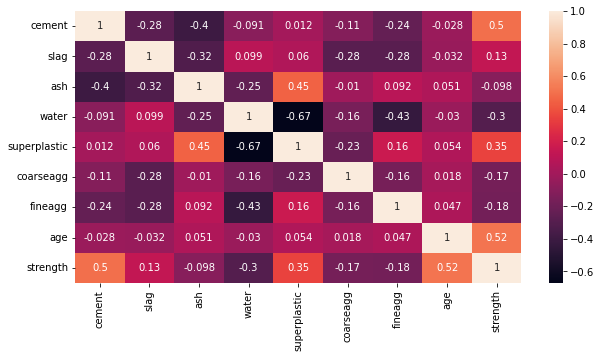

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
cor= data2.corr()
sns.heatmap(cor, annot=True)

1.   Superplastic and Water are highly correlated (Corr_coef=0.67).
2.   Cement and Age are highly correlated with strength (Corr_coeff=0.5).
3.   Rest of them don't have any correlation.

<AxesSubplot:xlabel='cement', ylabel='strength'>

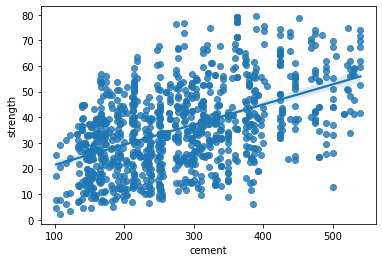

In [10]:
import seaborn as sns
sns.regplot(x=data2['cement'], y=data2['strength'])

<AxesSubplot:xlabel='age', ylabel='strength'>

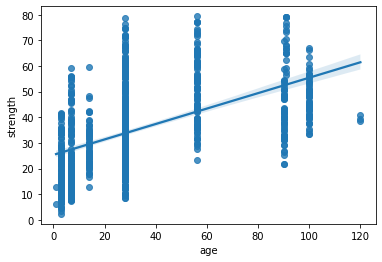

In [11]:
sns.regplot(x=data2['age'], y=data2['strength'])

<AxesSubplot:xlabel='superplastic', ylabel='water'>

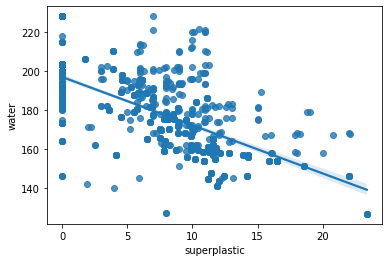

In [12]:
sns.regplot(x=data2['superplastic'], y=data2['water'])

# Check for NULL values

In [13]:
data2.isnull().sum()

cement           0
slag             2
ash              0
water            9
superplastic    10
coarseagg        0
fineagg          5
age             59
strength         4
dtype: int64

In [14]:
# Removing NULL values
data3=data2.dropna()
data3.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

In [15]:
# Imputing NULL values
data4=data2.copy()
data4['slag']=data4['slag'].fillna(float(data4['slag'].mode()))
data4['water']=data4['water'].fillna(float(data4['water'].mode()))
data4['superplastic']=data4['superplastic'].fillna(float(data4['superplastic'].mode()))
data4['fineagg']=data4['fineagg'].fillna(float(data4['fineagg'].mode()[0]))
data4['age']=data4['age'].fillna(float(data4['age'].mode()))
data4=data4.dropna()
data4.isnull().sum()

cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64

# Model creation

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [17]:
def input_and_output_split(data5):
  x=data5.drop('strength', axis=1)
  y=pd.DataFrame(data5['strength'], columns=['strength'])
  return(x,y)

In [18]:
def feature_scale(scale, x, y):
  #x=scale_x.fit_transform(x)
  #y=scale_y.fit_transform(y)
  scale_x=scale.fit(x)
  scale_y=scale.fit(y)
  x=scale_x.transform(x)
  y=scale_y.transform(y)
  return(scale_x, scale_y, x, y)

In [19]:
def model_creation(model_name, model, x, y):
  x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=7, shuffle=True)
  model.fit(x_train, y_train)
  y_pred=model.predict(x_test)
  r2_scr=metrics.r2_score(y_test, y_pred)
  rmse_scr=np.sqrt(metrics.mean_squared_error(y_test, y_pred))
  global s
  s=s.append({
      'model_name':model_name,
      'model_stats':model,
      'r2_score':r2_scr,
      'rmse_score':rmse_scr
      }, ignore_index = True)
  return model

In [20]:
def final_model(data_final, scaled):
  global s
  model=[]
  scale_x=scale_y=0
  s=pd.DataFrame({})
  x, y = input_and_output_split(data_final)
  if (scaled==1):
    scale_x, scale_y, x, y = feature_scale(StandardScaler(), x, y)
  elif (scaled==2):
    scale_x, scale_y, x, y = feature_scale(MinMaxScaler(), x, y)
  model.append(model_creation('LinearRegression', LinearRegression(), x, y))
  model.append(model_creation('Lasso', Lasso(max_iter=10e6), x, y))
  model.append(model_creation('Ridge', Ridge(max_iter=10e6), x, y))
  model.append(model_creation('KNeighborsRegressor', KNeighborsRegressor(), x, y))
  model.append(model_creation('SupportVectorRegressor', SVR(), x, y))
  model.append(model_creation('RandomForestRegressor', RandomForestRegressor(random_state=7), x, y))
  model.append(model_creation('AdaBoostRegressor', AdaBoostRegressor(random_state=7), x, y))
  model.append(model_creation('XGBRegressor', XGBRegressor(random_state=7), x, y))
  display(s.sort_values(by="r2_score",ascending = False))

  print("***********************************", scale_x, scale_y)

  return scale_x, scale_y, model

In [21]:
# with NULLs dropped
# without feature_scaling
scale_x, scale_y, model=final_model(data3, 0)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,model_name,model_stats,r2_score,rmse_score
7,XGBRegressor,"XGBRegressor(base_score=0.5, booster='gbtree',...",0.915132,4.682976
5,RandomForestRegressor,"(DecisionTreeRegressor(max_features='auto', ra...",0.895641,5.192957
6,AdaBoostRegressor,"(DecisionTreeRegressor(max_depth=3, random_sta...",0.791458,7.340861
0,LinearRegression,LinearRegression(),0.776304,7.602899
2,Ridge,Ridge(max_iter=10000000.0),0.776304,7.602902
1,Lasso,Lasso(max_iter=10000000.0),0.775409,7.618100
3,KNeighborsRegressor,KNeighborsRegressor(),0.682322,9.060325
4,SupportVectorRegressor,SVR(),0.214528,14.246734


*********************************** 0 0


In [22]:
df=pd.DataFrame({
    'cement':520,
    'slag':0.0,
    'ash':0.0,
    'water':170.0,
    'superplastic':5.2,
    'coarseagg':855.0,
    'fineagg':855.0,
    'age':28.0
    }, index=[1])

# here we don't need scaling

for i in model:
  if (i == s[s['r2_score']==s['r2_score'].max()]['model_stats'].reset_index(drop=True).loc[0]):
    print("Best Model = ", i)
    print("Value = ", i.predict(df))

Best Model =  XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=1,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.300000012, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=6, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=100, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=7, reg_alpha=0,
             reg_lambda=1, ...)
Value =  [56.06955]


### https://stackoverflow.com/questions/38058774/scikit-learn-how-to-scale-back-the-y-predicted-result

### standard scaling not working properly, 
### not ab

# With NULLs imputed with MODE
# with Standard_Scaling
scale_x, scale_y, model=final_model(data4, 1)

df=pd.DataFrame({
    'cement':520,
    'slag':0.0,
    'ash':0.0,
    'water':170.0,
    'superplastic':5.2,
    'coarseagg':855.0,
    'fineagg':855.0,
    'age':28.0
    }, index=[1])

df=pd.DataFrame({
    'cement':520,
    'slag':0.0,
    'ash':0.0,
    'water':170.0,
    'superplastic':5.2,
    'coarseagg':855.0,
    'fineagg':855.0,
    'age':28.0
    }, index=[1])

df2=pd.DataFrame({
    'cement':520
}, index=[1])

df=scale_x.fit_transform(df)
df2=scale_y.fit_transform(df2)

for i in model:
  if (i == s[s['r2_score']==s['r2_score'].max()]['model_stats'].reset_index(drop=True).loc[0]):
    print("Best Model = ", i)
    print("Value = ", i.predict(df))
    y_pred=i.predict(df)
    print(scale_y.inverse_transform(y_pred.reshape(-1, 1)))
    
    
    
    
    
    """#print(scale_y.inverse_transform(y_pred.reshape(-1, 1)))
    print(pd.DataFrame(y_pred*[1,0,0,0,0,0,0,0]))
    print(pd.DataFrame(y_pred*[1,0,0,0,0,0,0,0]).T.shape)
    #print(y_pred.reshape(-1, 1).shape)
    print(scale_y.inverse_transform(pd.DataFrame(y_pred*[1,0,0,0,0,0,0,0]).T))
    print("GGGGGGGGGG", type(y_pred))
    yyy=np.array([0.333333333333333333])
    print(scale_y.inverse_transform(pd.DataFrame(yyy*[1,0,0,0,0,0,0,0]).T))
    #y_pred=scale.inverse_transform(np.array(y_pred.reshape(-1, 1)))
    #print(y_pred.shape)
    #print(y_pred)"""